## Importing libraries

In [1]:
import os
import h5py
import numpy as np
import json
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display, clear_output
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
sns.set_style('whitegrid')

In [2]:
from keras import optimizers
from keras.applications.vgg16 import VGG16
from keras.models import Sequential, load_model, Model
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D, Activation, Dropout, Flatten, Dense, Input
from keras.regularizers import l2, l1
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import  array_to_img, img_to_array, load_img
from keras.callbacks import ModelCheckpoint, History
from keras import backend as K
from tensorflow.keras.utils import get_file
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## creating function for visualisation

In [14]:
def plot_metrics(hist, stop=50):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
                            
    axes = axes.flatten()

    axes[0].plot(range(stop), hist['accuracy'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist['val_accuracy'], label='Validation', color='#03507E')
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist['loss'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist['val_loss'], label='Validation', color='#03507E')
    axes[1].set_title('Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right')
                             
    plt.tight_layout();
    
    print("Best Model:") 
    print_best_model_results(hist)

In [34]:
def plot_acc_metrics(hist1, hist2, stop=50):
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(4.25,6))
                            
    axes = axes.flatten()
    
    axes[0].plot(range(stop), hist1['accuracy'], label='Training', color='#FF533D')
    axes[0].plot(range(stop), hist1['val_accuracy'], label='Validation', color='#03507E')
    axes[0].set_title('Training')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right')
                             
    axes[1].plot(range(stop), hist2['accuracy'], label='Training', color='#FF533D')
    axes[1].plot(range(stop), hist2['val_accuracy'], label='Validation', color='#03507E')
    axes[1].set_title('Fine-tuning')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='lower right')
                             
    plt.tight_layout();

## function to print best result of the model

In [5]:
def print_best_model_results(model_hist):
    best_epoch = np.argmax(model_hist['val_accuracy'])
    print('epoch:', best_epoch+1, \
    ', val_accuracy:', model_hist['val_accuracy'][best_epoch], \
    ', val_loss:', model_hist['val_loss'][best_epoch])

## bottleneck features

In [6]:
def save_bottleneck_features():
    datagen = ImageDataGenerator(rescale=1./255)
    
    model = VGG16(include_top=False, weights='imagenet')
    
    generator = datagen.flow_from_directory(train_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode=None, shuffle=False)
    bottleneck_features_train = model.predict(generator, nb_train_samples // batch_size)
    np.save(location+'/bottleneck_features_train.npy', bottleneck_features_train)
    
    generator = datagen.flow_from_directory(validation_data_dir, target_size=(img_width, img_height), batch_size=batch_size, class_mode=None, shuffle=False)
    bottleneck_features_validation = model.predict(generator, nb_validation_samples // batch_size)
    np.save(location+'/bottleneck_features_validation.npy', bottleneck_features_validation)

def train_top_model():
    train_data = np.load(location+'/bottleneck_features_train.npy')
    train_labels = np.array([0] * (nb_train_samples // 2) + [1] * (nb_train_samples // 2))
    
    validation_data = np.load(location+'/bottleneck_features_validation.npy')
    validation_labels = np.array([0] * (nb_validation_samples // 2) + [1] * (nb_validation_samples // 2))
    
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256,activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    
    checkpoint = ModelCheckpoint(filepath=top_model_weights_path, monitor='val_acc', verbose=1, save_best_only=True, save_weights_only=False, mode='auto')
    
    fit = model.fit_generator(train_data, train_labels, epochs=epochs, batch_size=batch_size,validation_data=(validation_data,validation_labels), callbacks=[checkpoint])
    
    with open(location+'/top_history.txt', 'w') as f:
        json.dump(fit.history, f) 
        
    return model, fit.history

## traning top model (vgg16)

In [7]:

def train_top_model():
    # Load bottleneck features
    train_data = np.load(location + '/bottleneck_features_train.npy')
    train_labels = np.array([0] * (nb_train_samples // 2) + [1] * (nb_train_samples // 2))
    
    validation_data = np.load(location + '/bottleneck_features_validation.npy')
    validation_labels = np.array([0] * (nb_validation_samples // 2) + [1] * (nb_validation_samples // 2))
    
    # Define the top model
    model = Sequential()
    model.add(Flatten(input_shape=train_data.shape[1:]))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(optimizer='rmsprop', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    # Define ModelCheckpoint to save the best model
    checkpoint = ModelCheckpoint(filepath=top_model_weights_path, 
                                 monitor='val_accuracy',  # Use 'val_accuracy' instead of 'val_acc'
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=True,  # Save the full model
                                 mode='auto')
    
    # Fit the model using `fit()` instead of `fit_generator`
    fit = model.fit(train_data, 
                    train_labels, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    validation_data=(validation_data, validation_labels), 
                    callbacks=[checkpoint])
    
    # Save training history
    with open(location + '/top_history.txt', 'w') as f:
        json.dump(fit.history, f)
    
    # Save the entire model manually
    try:
        model.save(location + '/top_model_final.h5')
        print("Model saved successfully.")
    except Exception as e:
        print(f"Error saving the model: {e}")
    
    return model, fit.history


def finetune_binary_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256,256,3))
    print("Model loaded.")
    
    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(1, activation='sigmoid'))
    
    top_model.load_weights(top_model_weights_path)
    
    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))
    
    for layer in model.layers[:25]:
        layer.trainable = False
    
    model.compile(loss='binary_crossentropy', optimizer=optimizers.SGD(lr=1e-4, momentum=0.9), metrics=['accuracy'])
    
    train_datagen = ImageDataGenerator(rescale = 1./255, zoom_range=0.2, shear_range=0.2, horizontal_flip=True)
    
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(train_data_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='binary')
    
    validation_generator = test_datagen.flow_from_directory(validation_data_dir, target_size=(img_height, img_width), batch_size=batch_size, class_mode='binary')
    
    checkpoint = ModelCheckpoint(filepath=fine_tuned_model_path, monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=False, mode='auto')
    
    fit = model.fit_generator(train_generator, steps_per_epoch=nb_train_samples//batch_size, epochs=epochs, validation_data=validation_generator, validation_steps=nb_validation_samples//batch_size, verbose=1, callbacks=[checkpoint])
    
    with open(location+'/ft_history.txt', 'w') as a:
        json.dump(fit.history, a)
        
    return model, fit.history  

## fintuned model

In [8]:
def finetune_binary_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    print("Base model loaded.")
    
    # Define the top model
    top_model = Sequential()
    top_model.add(Flatten(input_shape=base_model.output_shape[1:]))
    top_model.add(Dense(256, activation='relu'))
    top_model.add(Dropout(0.5))
    top_model.add(Dense(1, activation='sigmoid'))
    
    # Load weights for the top model
    top_model.load_weights(top_model_weights_path)
    
    # Combine base model and top model
    model = Model(inputs=base_model.input, outputs=top_model(base_model.output))
    
    # Freeze the initial layers
    for layer in model.layers[:25]:
        layer.trainable = False
    
    # Compile the model
    model.compile(loss='binary_crossentropy', 
                  optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.9), 
                  metrics=['accuracy'])
    
    # Data augmentation for training
    train_datagen = ImageDataGenerator(rescale=1./255, 
                                       zoom_range=0.2, 
                                       shear_range=0.2, 
                                       horizontal_flip=True)
    
    # Data preparation for validation
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    # Data generators
    train_generator = train_datagen.flow_from_directory(train_data_dir, 
                                                        target_size=(img_height, img_width), 
                                                        batch_size=batch_size, 
                                                        class_mode='binary')
    
    validation_generator = test_datagen.flow_from_directory(validation_data_dir, 
                                                            target_size=(img_height, img_width), 
                                                            batch_size=batch_size, 
                                                            class_mode='binary')
    
    # ModelCheckpoint callback for saving the best model
    checkpoint = ModelCheckpoint(filepath=fine_tuned_model_path, 
                                 monitor='val_accuracy', 
                                 verbose=1, 
                                 save_best_only=True, 
                                 save_weights_only=False, 
                                 mode='auto')
    
    # Use fit() instead of fit_generator
    fit = model.fit(train_generator, 
                    steps_per_epoch=nb_train_samples // batch_size, 
                    epochs=epochs, 
                    validation_data=validation_generator, 
                    validation_steps=nb_validation_samples // batch_size, 
                    verbose=1, 
                    callbacks=[checkpoint])
    
    # Save the training history
    with open(location + '/ft_history.txt', 'w') as a:
        json.dump(fit.history, a)
    
    # Save the entire model manually if needed
    try:
        model.save(location + '/fine_tuned_final_model.h5')
        print("Model saved successfully.")
    except Exception as e:
        print(f"Error saving the model: {e}")
    
    return model, fit.history


## Evaluation matrics function

In [9]:
def evaluate_binary_model(model, directory, labels):
    datagen = ImageDataGenerator(rescale=1./255)
    
    generator = datagen.flow_from_directory(directory, target_size=(img_height,img_width), batch_size=batch_size, class_mode='binary', shuffle=False)
    
    predictions = model.predict(generator, len(labels))
    
    pred_labels = [0 if i<0.5 else 1 for i in predictions]
    
    print('')
    print(classification_report(validation_labels, pred_labels))
    print('')
    cm = confusion_matrix(validation_labels, pred_labels)
    return cm

## Defining paths

In [10]:
location = r'C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2'
top_model_weights_path = location+'/top_model_weights.weights.h5'
fine_tuned_model_path = location+'/ft_model.h5'

train_data_dir = location+'/training'
validation_data_dir = location+'/validation'
train_samples = [len(os.listdir(train_data_dir+'/'+i)) for i in sorted(os.listdir(train_data_dir))]
nb_train_samples = 1840
validation_samples = [len(os.listdir(validation_data_dir+'/'+i)) for i in sorted(os.listdir(validation_data_dir))]
nb_validation_samples = 460

img_width, img_height = 256,256
epochs = 50
batch_size = 16

In [ ]:
# saving bottleneck features
save_bottleneck_features()

Found 1840 images belonging to 2 classes.
115/115 [==============================] - 281s 2s/step
Found 460 images belonging to 2 classes.
29/29 [==============================] - 156s 5s/step


In [12]:
d2_model1, d2_history1 = train_top_model()

Epoch 1/50
115/115 [==============================] - ETA: 0s - loss: 1.1432 - accuracy: 0.7582
Epoch 1: val_accuracy improved from -inf to 0.80000, saving model to C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2\top_model_weights.weights.h5
115/115 [==============================] - 25s 195ms/step - loss: 1.1432 - accuracy: 0.7582 - val_loss: 0.4286 - val_accuracy: 0.8000
Epoch 2/50
115/115 [==============================] - ETA: 0s - loss: 0.4087 - accuracy: 0.8418
Epoch 2: val_accuracy improved from 0.80000 to 0.91087, saving model to C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2\top_model_weights.weights.h5
115/115 [==============================] - 22s 189ms/step - loss: 0.4087 - accuracy: 0.8418 - val_loss: 0.2263 - val_accuracy: 0.9109
Epoch 3/50
115/115 [==============================] - ETA: 0s - loss: 0.3445 - accuracy: 0.8636
Epoch 3: val_accuracy did not improve from 0.91087
115/115 [=======

115/115 [==============================] - ETA: 0s - loss: 0.0246 - accuracy: 0.9908
Epoch 28: val_accuracy did not improve from 0.92609
115/115 [==============================] - 10s 90ms/step - loss: 0.0246 - accuracy: 0.9908 - val_loss: 0.5274 - val_accuracy: 0.9196
Epoch 29/50
115/115 [==============================] - ETA: 0s - loss: 0.0364 - accuracy: 0.9891
Epoch 29: val_accuracy did not improve from 0.92609
115/115 [==============================] - 11s 94ms/step - loss: 0.0364 - accuracy: 0.9891 - val_loss: 0.5119 - val_accuracy: 0.9217
Epoch 30/50
115/115 [==============================] - ETA: 0s - loss: 0.0298 - accuracy: 0.9908
Epoch 30: val_accuracy did not improve from 0.92609
115/115 [==============================] - 10s 91ms/step - loss: 0.0298 - accuracy: 0.9908 - val_loss: 0.5908 - val_accuracy: 0.9174
Epoch 31/50
115/115 [==============================] - ETA: 0s - loss: 0.0299 - accuracy: 0.9891
Epoch 31: val_accuracy did not improve from 0.92609
115/115 [========

C:\Users\91951\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Best Model:
epoch: 42 , val_accuracy: 0.9304347634315491 , val_loss: 0.7161393761634827


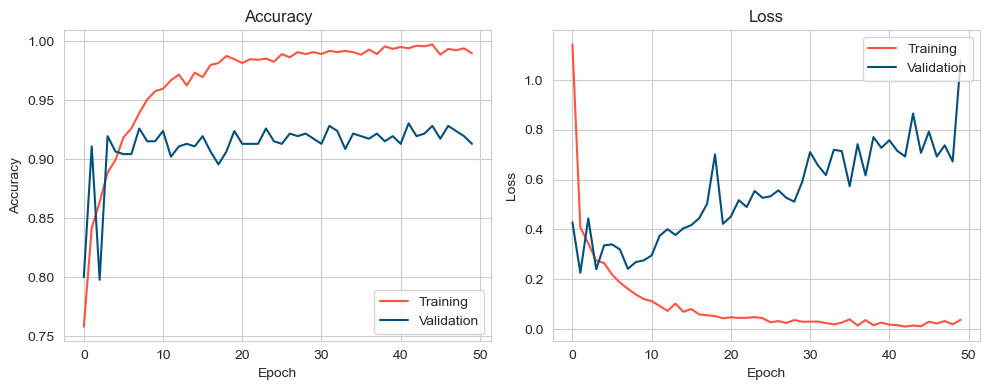

In [ ]:
# top modle training vizulization
plot_metrics(d2_history1)


In [16]:
ft_model, ft_history = finetune_binary_model()

Base model loaded.
Found 1840 images belonging to 2 classes.
Found 460 images belonging to 2 classes.
Epoch 1/50
115/115 [==============================] - ETA: 0s - loss: 0.6078 - accuracy: 0.9299
Epoch 1: val_accuracy improved from -inf to 0.93304, saving model to C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2\ft_model.h5
115/115 [==============================] - 728s 6s/step - loss: 0.6078 - accuracy: 0.9299 - val_loss: 0.6696 - val_accuracy: 0.9330
Epoch 2/50
115/115 [==============================] - ETA: 0s - loss: 0.5898 - accuracy: 0.9272
Epoch 2: val_accuracy did not improve from 0.93304
115/115 [==============================] - 685s 6s/step - loss: 0.5898 - accuracy: 0.9272 - val_loss: 0.7352 - val_accuracy: 0.9286
Epoch 3/50
115/115 [==============================] - ETA: 0s - loss: 0.7388 - accuracy: 0.9190  
Epoch 3: val_accuracy did not improve from 0.93304
115/115 [==============================] - 8145s 71s/step - loss: 0.7388

Epoch 29/50
115/115 [==============================] - ETA: 0s - loss: 0.6431 - accuracy: 0.9228
Epoch 29: val_accuracy did not improve from 0.93527
115/115 [==============================] - 306s 3s/step - loss: 0.6431 - accuracy: 0.9228 - val_loss: 0.7353 - val_accuracy: 0.9286
Epoch 30/50
115/115 [==============================] - ETA: 0s - loss: 0.6624 - accuracy: 0.9196
Epoch 30: val_accuracy did not improve from 0.93527
115/115 [==============================] - 312s 3s/step - loss: 0.6624 - accuracy: 0.9196 - val_loss: 0.6535 - val_accuracy: 0.9353
Epoch 31/50
115/115 [==============================] - ETA: 0s - loss: 0.6864 - accuracy: 0.9201
Epoch 31: val_accuracy did not improve from 0.93527
115/115 [==============================] - 291s 3s/step - loss: 0.6864 - accuracy: 0.9201 - val_loss: 0.7353 - val_accuracy: 0.9286
Epoch 32/50
115/115 [==============================] - ETA: 0s - loss: 0.5408 - accuracy: 0.9299
Epoch 32: val_accuracy did not improve from 0.93527
115/115 

In [42]:

ft_model = load_model(location+'/ft_model.h5')

In [18]:
with open(r'C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2\top_history.txt') as f:    
    top_history = json.load(f)


In [19]:
with open(r'C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2\ft_history.txt') as f:    
    ft_history = json.load(f)

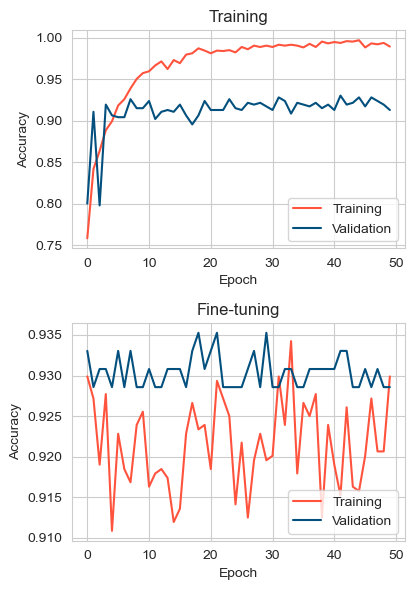

In [35]:
plot_acc_metrics(top_history, ft_history)

Best Model:
epoch: 19 , val_accuracy: 0.9352678656578064 , val_loss: 0.6839175820350647


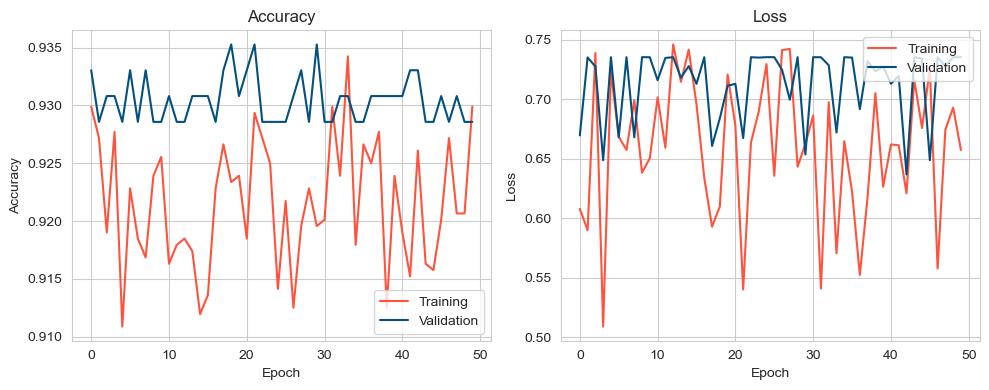

In [ ]:

plot_metrics(ft_history) # sgd with lr = 0.0001, sigmoid, with l2 = 0.001

In [22]:
validation_labels = np.array([0] * (nb_validation_samples // 2) + [1] * (nb_validation_samples // 2))


In [ ]:
# classification report
cm = evaluate_binary_model(ft_model, validation_data_dir, validation_labels)



Found 460 images belonging to 2 classes.
29/29 [==============================] - 57s 2s/step

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       230
           1       0.94      0.92      0.93       230

    accuracy                           0.93       460
   macro avg       0.93      0.93      0.93       460
weighted avg       0.93      0.93      0.93       460




In [ ]:
# labels for cm
heatmap_labels = ['00-damage', '01-whole']

<Axes: >

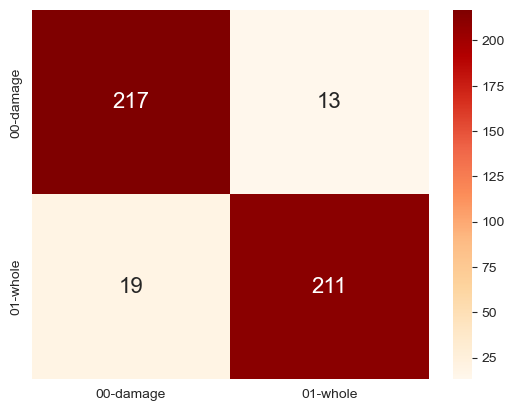

In [ ]:
# confusion matrix for finetuned model
sns.heatmap(cm, annot=True, annot_kws={"size":16}, fmt='g', cmap='OrRd', xticklabels= heatmap_labels, yticklabels= heatmap_labels)


<Axes: >

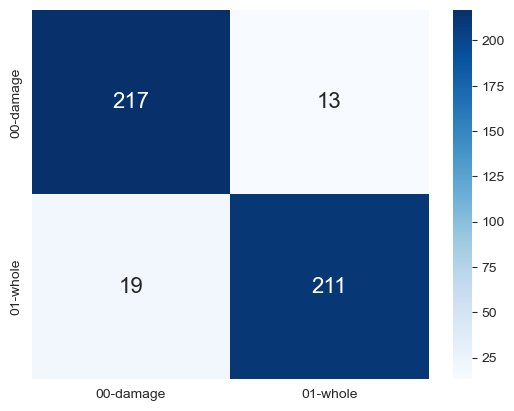

In [26]:
sns.heatmap(cm, annot=True, annot_kws={"size":16}, fmt='g', cmap='Blues', xticklabels=heatmap_labels, yticklabels=heatmap_labels)


## Creating a pipeline 

In [50]:
def pipe2(image_path, model):
#     urllib.request.urlretrieve(image_path, 'save.jpg')
    img = load_img(image_path, target_size=(256,256))
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)/255
    pred = model1.predict(x)
    print("Validating that damage exists....")
    print(pred)
    if(pred[0][0]<=0.5):
        print("Validation complete - proceed to location and severity determination")
    else:
        print ("Are you sure that your car is damaged? Please submit another picture of the damage.")
        print ("Hint: Try zooming in/out, using a different angle or different lighting")      

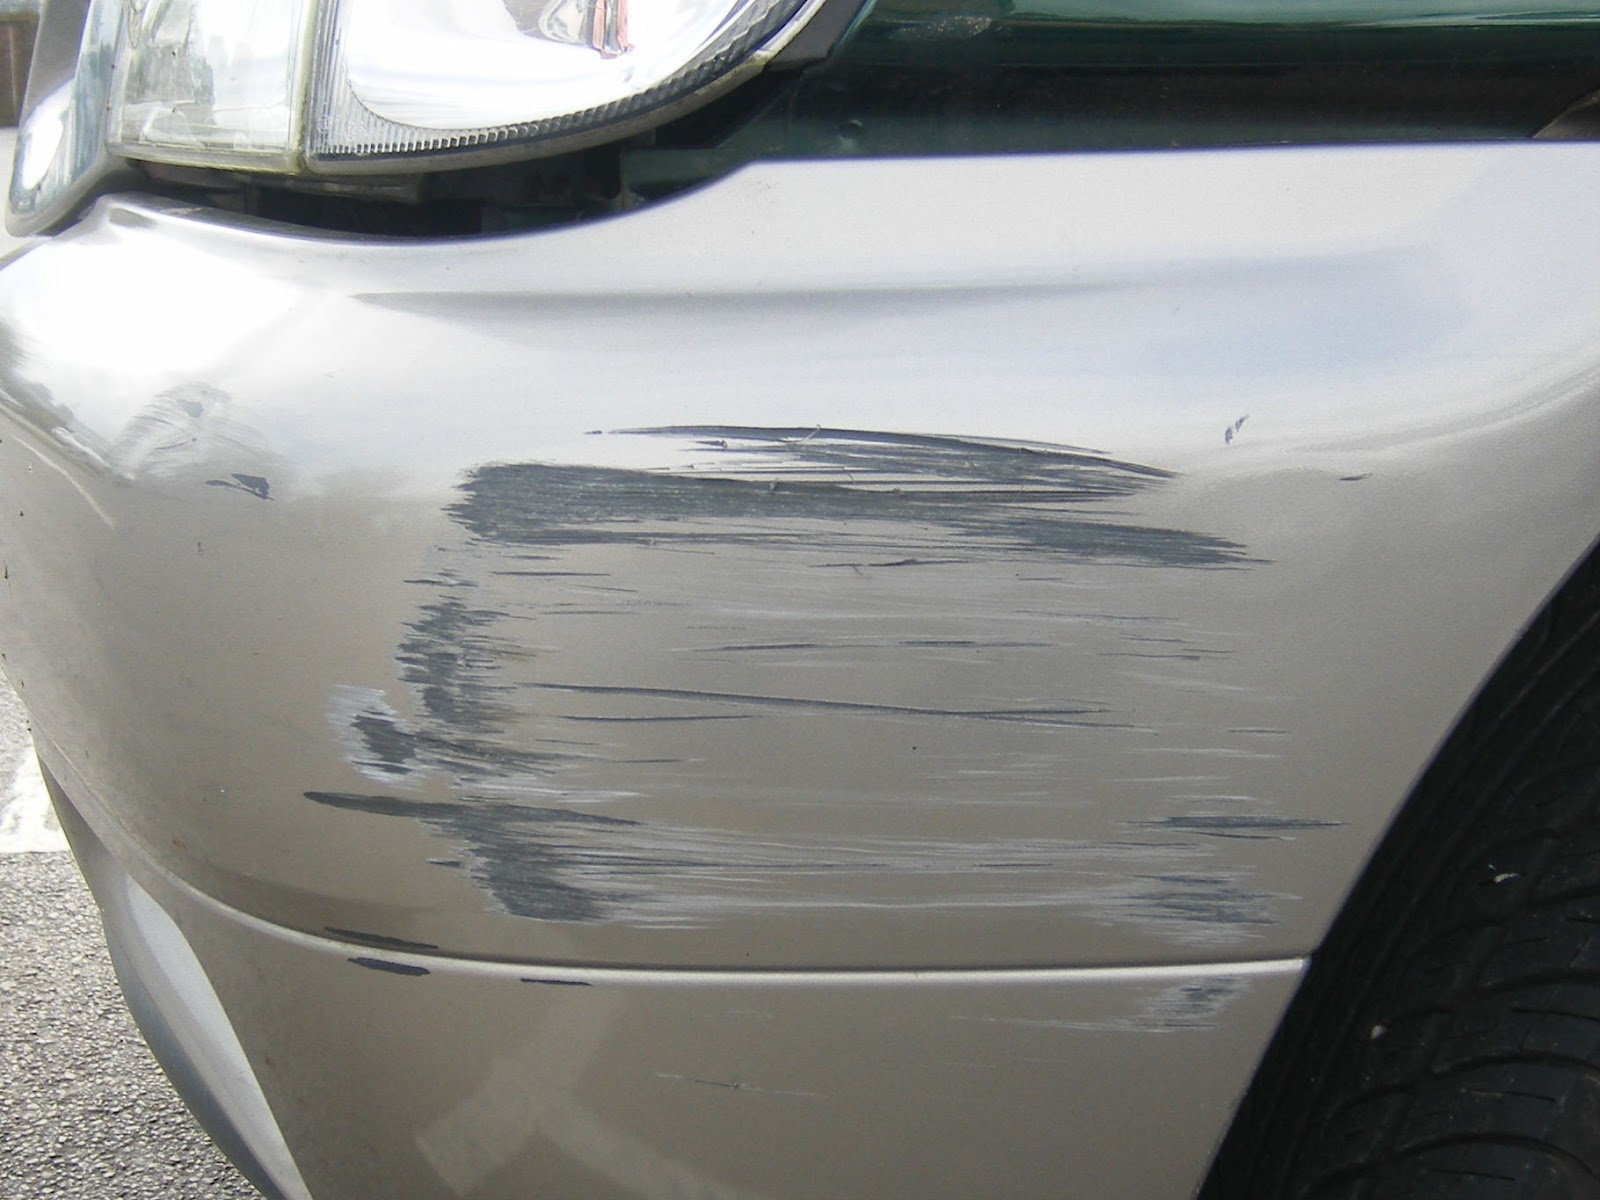

In [28]:
Image('http://3.bp.blogspot.com/-PrRY9XxCqYQ/UDNutnMI7LI/AAAAAAAABdw/UGygghh-hRA/s1600/Bumper+scuff.JPG')

In [51]:
pipe2(r"C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data1a\training\0-damage\0004.JPEG", ft_model)

1/1 [==============================] - 1s 889ms/step
Validating that damage exists....
[[3.305161e-13]]
Validation complete - proceed to location and severity determination


In [31]:
def get_edge_cases(model, directory, exp_result):
    img_list = os.listdir(directory)
    edge_list = []
    for name in img_list:
        img = load_img(directory+name, target_size=(256, 256)) # this is a PIL image 
        x = img_to_array(img) # this is a Numpy array with shape (3, 256, 256)
        x = x.reshape((1,) + x.shape)/255 # this is a Numpy array with shape (1, 3, 256, 256)
        pred_prob = model.predict(x)
        if pred_prob <=0.5:
            pred = 0
        else:
            pred = 1
        if pred != exp_result:
            edge_list.append(name)
    return edge_list

In [44]:
# from tensorflow.keras.models import load_model

# # Assuming you've already loaded or trained your model
#
# Save the model in .keras format
ft_model.save(r'C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2\your_model.keras', save_format='keras')


In [49]:
model1 = load_model(r'C:\Users\91951\OneDrive\Desktop\pythonProject\sem 3\capstone project\data2\data2_f\data2\your_model.keras')
